## european.py (european)

<Axes: xlabel='underlying price'>

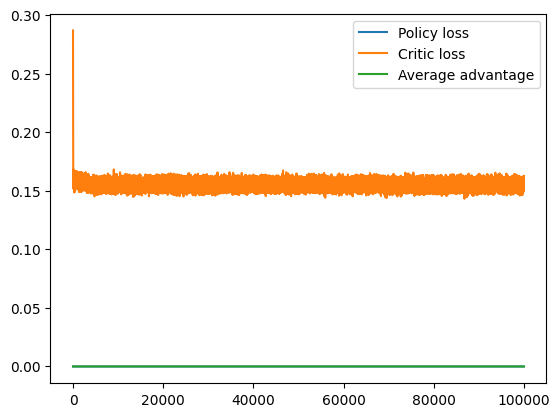

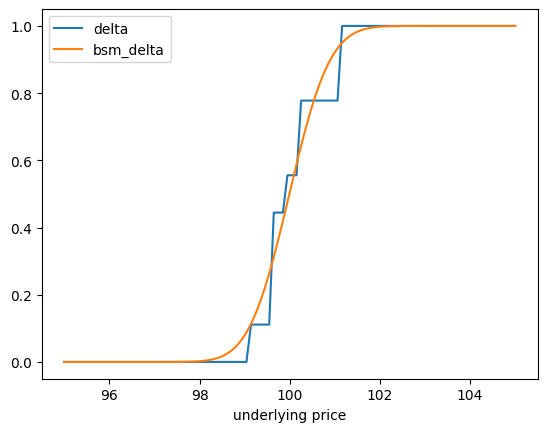

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)
from model import PPOAgent, compute_returns, compute_rewards, build_state, calc_policy_loss, calc_value_loss, calc_entropy_bonus
from definitions import sample
from definitions import sim_step, E, bs as batch_size

enable_stop=False
kappa = 0.1 # risk aversion # it seems that it is not stated in the paper
gamma = 0.8 # value decay 0.8~0.9
lamb = 0.95 # advantage decay # it seems that it is not stated in the paper

action_dim = 10

agent = PPOAgent(input_dim=2, action_dim=10, hidden_dim=16)
optimizer = optim.Adam(agent.parameters(), lr=1e-3)

history = []
for _ in range(100000):
    x, ttms, dc, ds, curr_s = sample()

    # Forward
    states = build_state(x, ttms)
    stop_action, stop_log_prob, hedge_action, hedge_log_prob, \
        values, exercise_mask, rewards, stop_entropy, hedge_entropy = \
            compute_rewards(
                agent, action_dim, batch_size, sim_step, E, dc, ds, curr_s, states, kappa=kappa, enable_stop=enable_stop
                )
    returns, advantages = compute_returns(rewards, values, exercise_mask, gamma=gamma, lam=lamb)
    
    # CRITICAL: Advantage Normalization (You keep deleting this!)
    valid_adv = advantages[~exercise_mask]
    advantages[~exercise_mask] = (valid_adv - valid_adv.mean()) / (valid_adv.std() + 1e-8)
    
    # Loss
    policy_loss = calc_policy_loss(stop_action, hedge_log_prob, stop_log_prob, exercise_mask, advantages, enable_stop=enable_stop)
    critic_loss = calc_value_loss(values, returns, exercise_mask) 
    entropy_bonus = calc_entropy_bonus(stop_action, stop_entropy, hedge_entropy, exercise_mask)

    # Backprop
    c1 = 0.5 
    c2 = 0.2
    optimizer.zero_grad()
    (policy_loss + c1 * critic_loss - c2 * entropy_bonus).backward()
    optimizer.step()

    avg_advantage = advantages[~exercise_mask].ravel().mean()
    history.append({
        "Policy loss":policy_loss.item(), 
        "Critic loss":critic_loss.item(), 
        "Average advantage":avg_advantage.item()
        })

import pandas as pd 
pd.DataFrame(history).plot()


import definitions

s = torch.linspace(95,105,100)
x = torch.log(s)
ttms = torch.ones_like(x) * 0.5
states = build_state(x, ttms)

stop_logits, hedge_logits, values = agent(states)

pd.DataFrame({
    "underlying price" : s.cpu().tolist(),
    "delta" : (hedge_logits.argmax(1) / ( action_dim -1 )).cpu().tolist(),
    "bsm_delta" : definitions.bsm_delta(x, ttms, 100).cpu().tolist()
}).set_index("underlying price").plot()#.plot.scatter(x="underlying price", y="delta")


## european_ee.py (european + early exercise)

<Axes: xlabel='underlying price'>

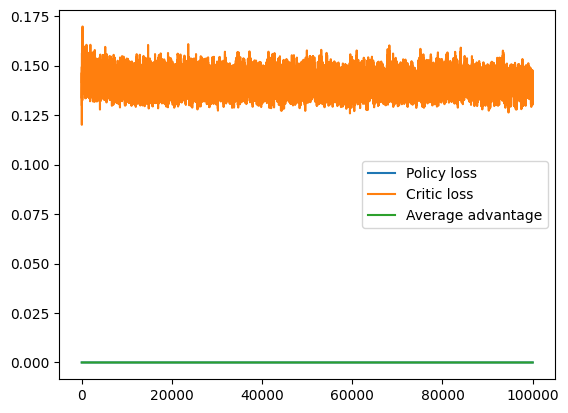

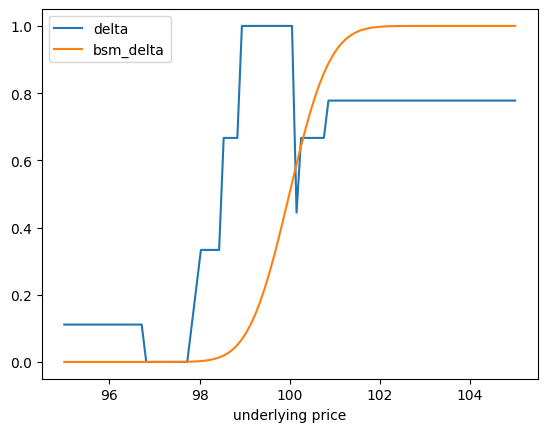

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)
from model import PPOAgent, compute_returns, compute_rewards, build_state, calc_policy_loss, calc_value_loss, calc_entropy_bonus
from definitions import sample
from definitions import sim_step, E, bs as batch_size

enable_stop=True
kappa = 0.1 # risk aversion # it seems that it is not stated in the paper
gamma = 0.8 # value decay 0.8~0.9
lamb = 0.95 # advantage decay # it seems that it is not stated in the paper

action_dim = 10

agent = PPOAgent(input_dim=2, action_dim=10, hidden_dim=16)
optimizer = optim.Adam(agent.parameters(), lr=1e-3)

history = []
for _ in range(100000):
    x, ttms, dc, ds, curr_s = sample()

    # Forward
    states = build_state(x, ttms)
    stop_action, stop_log_prob, hedge_action, hedge_log_prob, \
        values, exercise_mask, rewards, stop_entropy, hedge_entropy = \
            compute_rewards(
                agent, action_dim, batch_size, sim_step, E, dc, ds, curr_s, states, kappa=kappa, enable_stop=enable_stop
                )
    returns, advantages = compute_returns(rewards, values, exercise_mask, gamma=gamma, lam=lamb)
    
    # CRITICAL: Advantage Normalization (You keep deleting this!)
    valid_adv = advantages[~exercise_mask]
    advantages[~exercise_mask] = (valid_adv - valid_adv.mean()) / (valid_adv.std() + 1e-8)
    
    # Loss
    policy_loss = calc_policy_loss(stop_action, hedge_log_prob, stop_log_prob, exercise_mask, advantages, enable_stop=enable_stop)
    critic_loss = calc_value_loss(values, returns, exercise_mask) 
    entropy_bonus = calc_entropy_bonus(stop_action, stop_entropy, hedge_entropy, exercise_mask)

    # Backprop
    c1 = 0.5 
    c2 = 0.2
    optimizer.zero_grad()
    (policy_loss + c1 * critic_loss - c2 * entropy_bonus).backward()
    optimizer.step()

    avg_advantage = advantages[~exercise_mask].ravel().mean()
    history.append({
        "Policy loss":policy_loss.item(), 
        "Critic loss":critic_loss.item(), 
        "Average advantage":avg_advantage.item()
        })

import pandas as pd 
pd.DataFrame(history).plot()


import definitions

s = torch.linspace(95,105,100)
x = torch.log(s)
ttms = torch.ones_like(x) * 0.5
states = build_state(x, ttms)

stop_logits, hedge_logits, values = agent(states)

pd.DataFrame({
    "underlying price" : s.cpu().tolist(),
    "delta" : (hedge_logits.argmax(1) / ( action_dim -1 )).cpu().tolist(),
    "bsm_delta" : definitions.bsm_delta(x, ttms, 100).cpu().tolist()
}).set_index("underlying price").plot()#.plot.scatter(x="underlying price", y="delta")


<Axes: xlabel='ttm'>

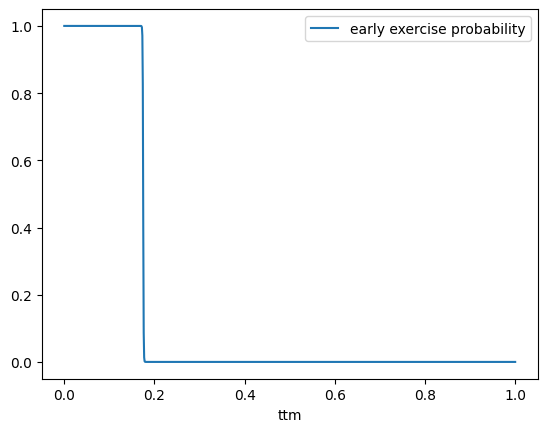

In [6]:
from torch.distributions import Categorical
import numpy as np 
ttms = torch.linspace(0,1,1000)
x = np.log(100) * torch.ones_like(ttms)
states = build_state(x, ttms)

stop_logits, hedge_logits, values = agent(states)

dist = Categorical(logits=stop_logits)
dist.probs[:,1]
pd.DataFrame({
    "ttm" : ttms.cpu().tolist(),
    "early exercise probability": dist.probs[:,1].cpu().tolist(),
    # "delta" : (hedge_logits.argmax(1) / ( action_dim -1 )).cpu().tolist(),
    # "bsm_delta" : definitions.bsm_delta(x, ttms, 100).cpu().tolist()
}).set_index("ttm").plot()#.plot.scatter(x="underlying price", y="delta")

